In [1]:
import pandas as pd

In [4]:
import os

In [69]:
final = pd.read_csv(os.path.join('/arc/home/calvin/kko_host_paper','data_products/kko_full_cat.csv'))
final.set_index('chime_event_id',inplace=True)

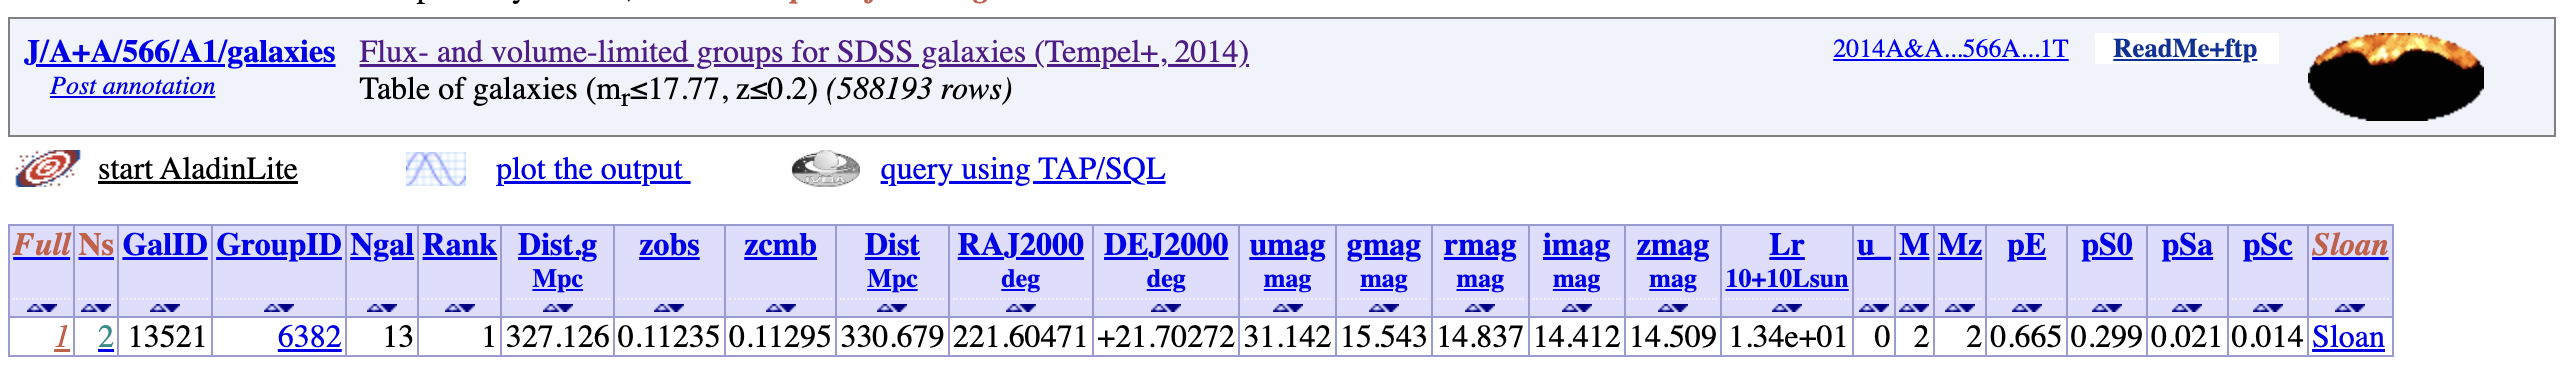

In [44]:
final[final['name'] == 'FRB20231204A'][['primary_ra','primary_dec','DM','dm_igm','DM_YT20','DM_NE2001','primary_z_spec','primary_mag']]

,primary_ra,primary_dec,DM,dm_igm,DM_YT20,DM_NE2001,primary_z_spec,primary_mag
chime_event_id,,,,,,,,
342256558,207.999403,48.120566,222.0,53.942359,32.003043,29.8287,0.0644,15.397451


In [230]:
import numpy as np
from scipy.optimize import minimize,approx_fprime



# Function to fit mu and sigma using MLE
def fit_mu_sigma(data):
    # Define the negative log-likelihood function for a normal distribution
    def neg_log_likelihood(params):
        mu, sigma = params
        # Avoid log(0) by ensuring sigma > 0
        if sigma <= 0:
            return np.inf
        # Compute the negative log-likelihood
        nll = -np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((data - mu) ** 2) / (2 * sigma**2))
        return nll
    def jac(params):
        """d logL / dmu, d logL / dsigma"""
        n = len(data)
        sigma = params[1]
        mu = params[0]
        dn_dmu = 1 / sigma**2 * np.sum(data - mu)
        dn_dsigma = -n / sigma + 1/sigma**3 * np.sum((data - mu)**2)
        return [-dn_dmu, -dn_dsigma]
    
    def hess(params):
        n = len(data)
        sigma = params[1]
        mu = params[0]
        dn_dmumu = - n / sigma**2
        dn_dmusigma = -2 / sigma**3 * np.sum(data - mu)
        dn_dsigsig = 2 * n / sigma**2 - 3 / sigma**4 * np.sum((data - mu)**2)
        return np.array([[-dn_dmumu, -dn_dmusigma],[-dn_dmusigma,-dn_dsigsig]])
        
    # Initial guesses for mu and sigma
    initial_guess = [np.mean(data), np.std(data)]
    
    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, initial_guess, method = 'Nelder-Mead', 
                       jac = jac,hess=hess)
    
    # Extract the fitted mu and sigma from the result
    mu_fit, sigma_fit = result.x
    #hessian_inv = result.hess_inv  # Inverse of the Hessian (covariance matrix)

    # Standard errors (square roots of the diagonal elements of the covariance matrix)
    #standard_errors = np.sqrt(np.diag(hessian_inv))
    hh = hess(result.x)
    unc= np.sqrt(np.diag(np.linalg.inv(hh)))
    return result.x,unc

import numpy as np
import matplotlib.pyplot as plt

/opt/pysetup/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:550: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  warn('Method %s does not use gradient information (jac).' % method,
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:555: RuntimeWarning: Method Nelder-Mead does not use Hessian information (hess).
  warn('Method %s does not use Hessian information (hess).' % method,


$\mu = 1.94 \pm 0.11$, $\sigma=0.40 \pm 0.13$
$\mu = 1.95 \pm 0.12$, $\sigma=0.40 \pm 0.13$
$\mu = 1.88 \pm 0.11$, $\sigma=0.40 \pm 0.18$


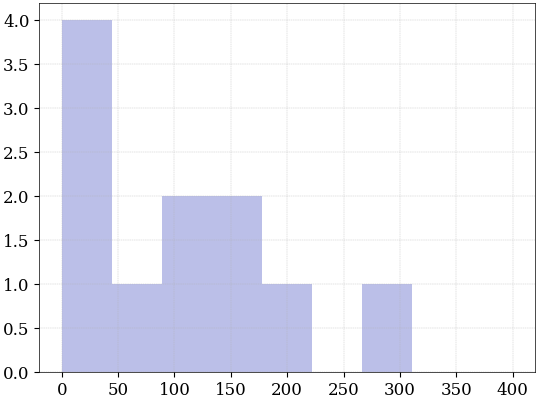

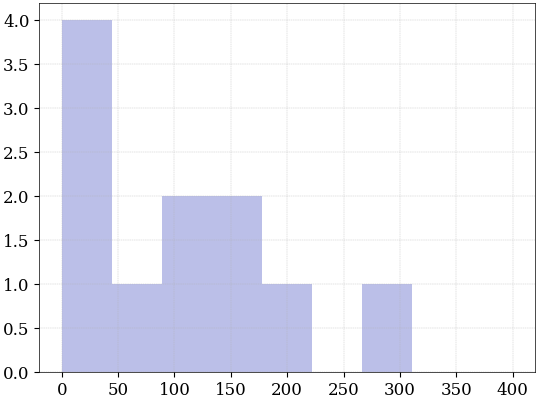

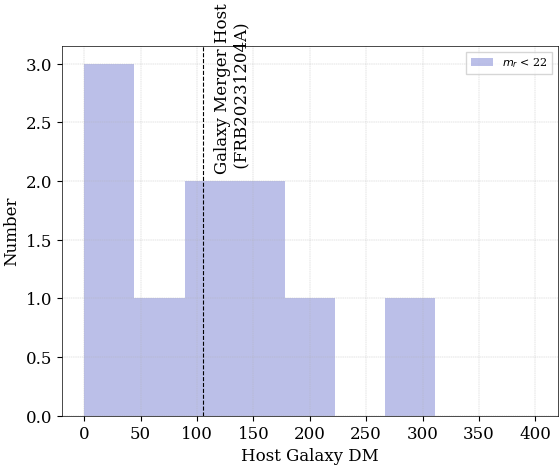

In [288]:
# Fiducial measurement: PATH P(O|x) > 0.9; m_r < 19.5; Use z_spec
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)
# Impact of relaxing PATH:
fiducial_lower_pox = (final['primary_P_Ox'] > 0.5) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)

fiducial_fainter_mag=(final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)

plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
bins = np.linspace(0,400,num = 10)
dm_host = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
plt.figure()
plt.hist(dm_host[fiducial_lower_pox],label = 'Lower P(O|x)',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial_fainter_mag],label = 'Fiducial',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial],label = '$m_r$ < 22',bins = bins,alpha = 0.3)
rest_frame_merger_dm = dm_host[final.index == 342256558].values / (1 + final['primary_z_spec'][final.index == 342256558].values)
plt.axvline(rest_frame_merger_dm,color = 'black',linestyle = '--')
plt.text(x = rest_frame_merger_dm + 10,y = 2.1,s = 'Galaxy Merger Host\n (FRB20231204A)',rotation = 90)
plt.legend()
plt.xlabel('Host Galaxy DM')
plt.ylabel('Number')
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_lower_pox]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_fainter_mag]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi=100)

In [251]:
from scipy.interpolate import interp1d

In [252]:
np.interp

<function numpy.interp(x, xp, fp, left=None, right=None, period=None)>

In [255]:
from frb.dm import igm
z_interp = np.geomspace(0.001,1,num = 30)
dm_igm_interp = []
for z_interp_i in z_interp:
    dm_igm_interp.append(igm.average_DM(z_interp_i))
dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = best_redshift)



In [263]:
dm_igm_interp= np.array([di.value for di in dm_igm_interp])

In [319]:
dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = [0.1,0.3])


In [266]:
def calc_dm_igm(final,source = 'zphot'):
    from frb.dm import igm
    best_redshifts = []
    for evid,row in final.iterrows():
        if source == 'zphot': 
            best_redshift = row['primary_z_phot_median']
        elif source == 'zspec':
            best_redshift = row['primary_z_spec']
        elif source == 'mix':
            if row['primary_z_spec'] > 0:
                best_redshift = row['primary_z_spec']
            elif row['primary_z_phot_median'] > 0:
                best_redshift = row['primary_z_phot_median']
            else:
                best_redshift = -1
   dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = best_redshifts)
   dm_igm[best_redshifts < 0] = np.nan
    final.at['dm_igm'] = dm_igm
    return final
def calc_dmh(final):
    dmh = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
    return dmh

In [273]:
final_zspec = calc_dm_igm(final,source = 'zspec')
final_zphot = calc_dm_igm(final,source = 'zphot')

dm_host_zspec = calc_dmh(final_zspec)
dm_host_zphot = calc_dmh(final_zphot)
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zspec[fiducial]))
print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sigma:.3f} \pm {sig_err:.3f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zphot[fiducial]))
print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sigma:.3f} \pm {sig_err:.3f}$")


$\mu = 1.940 \pm 0.11$, $\sigma=0.397 \pm 0.131$
$\mu = 1.940 \pm 0.11$, $\sigma=0.397 \pm 0.131$


In [297]:
lum = (final['primary_mag'] - dist_mod) > -20.548401478576412
nonlum = (final['primary_mag'] - dist_mod) <= -20.548401478576412

In [310]:
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22.5) * (final['primary_z_spec'] > 0)
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zspec[fiducial * lum]))
print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sigma:.3f} \pm {sig_err:.3f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zspec[fiducial * nonlum * has_specz]))
print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sigma:.3f} \pm {sig_err:.3f}$")

$\mu = 1.500 \pm 0.13$, $\sigma=0.397 \pm 8388608.000$
$\mu = 2.093 \pm 0.09$, $\sigma=0.397 \pm 0.117$


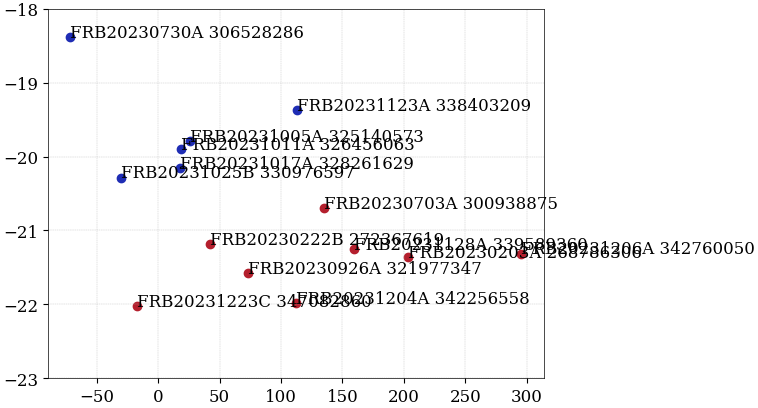

In [316]:
dist_mod = Planck18.distmod(np.clip(final['primary_z_spec'].values,a_min = 0,a_max = np.inf)).value
Mr = final['primary_mag'] - dist_mod
plt.figure()
plt.scatter(dm_host_zspec[fiducial * lum],(final['primary_mag'] - dist_mod)[fiducial * lum])
plt.scatter(dm_host_zspec[fiducial * nonlum],(final['primary_mag'] - dist_mod)[fiducial * nonlum])
plt.ylim(-23,-18)
for x,y,n,evid,include in zip(dm_host_zspec,(final['primary_mag'] - dist_mod),final['name'],final.index,fiducial):
    if include:
        plt.text(x=x,y=y,s=n + ' ' + str(evid))


In [45]:
from astropy.cosmology import Planck18

In [308]:
np.median(Mr[np.isfinite(Mr) * (0 < dist_mod) * (np.inf > dist_mod)])

-20.548401478576412

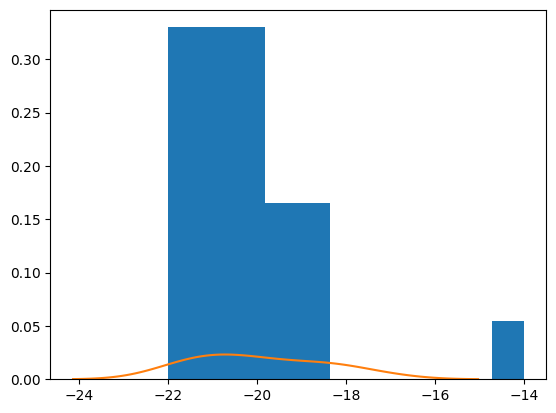

In [68]:
plt.figure()
plt.hist(,bins = np.linspace(-22,-14,num = 12),density=True)
pdf = pd.read_csv('/arc/home/calvin/FRB/frb/data/Galaxies/PDF_Mr.csv')
plt.plot(pdf['Mr'],pdf['PDF'])

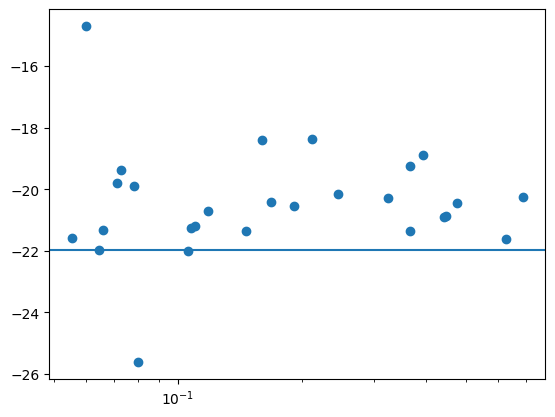

In [62]:
plt.figure()
plt.scatter(final['primary_z_spec'],final['primary_mag'] - dist_mod)
plt.axhline((final['primary_mag'] - dist_mod).loc[342256558])
plt.xscale('log')